# The Chosen Dataset
- We chose a dataset from the Stack Overflow Developer Survey, which contains information about developers worldwide such as experience, education, job roles, technologies used, and salaries. It is used to analyze trends in the software engineering field and understand factors affecting developers’ careers.

- Source: https://survey.stackoverflow.co/


# Task 1 — Exploratory Data Analysis & Visualization

- Imports

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

- Read data
- Take sample of 10000 row
- Select most important features

In [ ]:
df = pd.read_excel('stackoverflow_survey.xlsx')
# df = df.sample(n=10000, random_state=42)
df = df[['Age', 'EdLevel', 'Employment', 'WorkExp',
        'LearnCode', 'YearsCode', 'DevType', 'OrgSize',
        'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
        'aiSelect', 'AiSent', 'Country',
        'LanguageAdmired', 'ConvertedCompYearly', 'JobSat']]

# LearnCode, YearsCode, LanguageAdmired ==> Tech Score (Bonus)
# AIThreat, newRule, aiSelect, AiSent ==> Ai Score (Bonus)

C:\Users\kareem\AppData\Local\Temp\ipykernel_16056\964451782.py:1: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('survey_results_public.csv')


In [25]:
df.sample(10)

,Age,EdLevel,Employment,WorkExp,LearnCode,YearsCode,DevType,OrgSize,RemoteWork,Industry,AIThreat,NewRole,Country,LanguageAdmired,ConvertedCompYearly,JobSat
27495,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Independent contractor, freelancer, or self-em...",20.0,Online Courses or Certification (includes all ...,30.0,Academic researcher,100 to 499 employees,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20341,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,19.0,NaN,32.0,"Architect, software or solutions",Less than 20 employees,In-person,Fintech,No,I have somewhat considered changing my career ...,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,NaN,6.0
13180,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,14.0,Online Courses or Certification (includes all ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41338,45-54 years old,Some college/university study without earning ...,Student,30.0,Online Courses or Certification (includes all ...,5.0,Student,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25392,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,6.0,"Other online resources (e.g. standard search, ...",13.0,"Developer, AI apps or physical AI","1,000 to 4,999 employees","Hybrid (some remote, leans heavy to in-person)",Other:,No,I have transitioned into a new career and/or i...,Italy,NaN,40605.0,NaN
32620,45-54 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,15.0,Books / Physical media;Stack Overflow or Stack...,25.0,"Developer, desktop or enterprise applications",100 to 499 employees,In-person,Software Development,NaN,NaN,NaN,NaN,NaN,NaN
5259,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,21.0,NaN,27.0,"Architect, software or solutions","1,000 to 4,999 employees",In-person,Other:,Yes,I have somewhat considered changing my career ...,United Arab Emirates,Assembly;Bash/Shell (all shells);C;C++;Go;HTML...,247791.0,6.0
37415,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,17.0,Online Courses or Certification (includes all ...,22.0,"Developer, full-stack","10,000 or more employees",Remote,Software Development,No,I have neither consider or transitioned into a...,Chile,NaN,33930.0,8.0
33540,65 years or older,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Retired,50.0,"Other online resources (e.g. standard search, ...",56.0,Other (please specify):,NaN,NaN,NaN,NaN,NaN,Germany,R,NaN,NaN
20511,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,15.0,Technical documentation (is generated for/by t...,19.0,"Developer, back-end","1,000 to 4,999 employees",Remote,Software Development,Yes,I have somewhat considered changing my career ...,United Kingdom of Great Britain and Northern I...,NaN,NaN,8.0


In [26]:
print(df.dtypes)
df.info()

Age                        str
EdLevel                    str
Employment                 str
WorkExp                float64
LearnCode                  str
YearsCode              float64
DevType                    str
OrgSize                    str
RemoteWork                 str
Industry                   str
AIThreat                   str
NewRole                    str
Country                    str
LanguageAdmired            str
ConvertedCompYearly    float64
JobSat                 float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  49191 non-null  str    
 1   EdLevel              48149 non-null  str    
 2   Employment           48339 non-null  str    
 3   WorkExp              42893 non-null  float64
 4   LearnCode            33556 non-null  str    
 5   YearsCode            43042 non-null  

In [27]:
df.describe()

,WorkExp,YearsCode,ConvertedCompYearly,JobSat
count,42893.000000,43042.000000,2.394700e+04,26670.000000
mean,13.367403,16.570861,1.017615e+05,7.201950
std,10.800117,11.787610,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000e+00,0.000000
25%,5.000000,8.000000,3.817100e+04,6.000000
50%,10.000000,14.000000,7.532000e+04,8.000000
75%,20.000000,24.000000,1.205960e+05,8.000000
max,100.000000,100.000000,5.000000e+07,10.000000


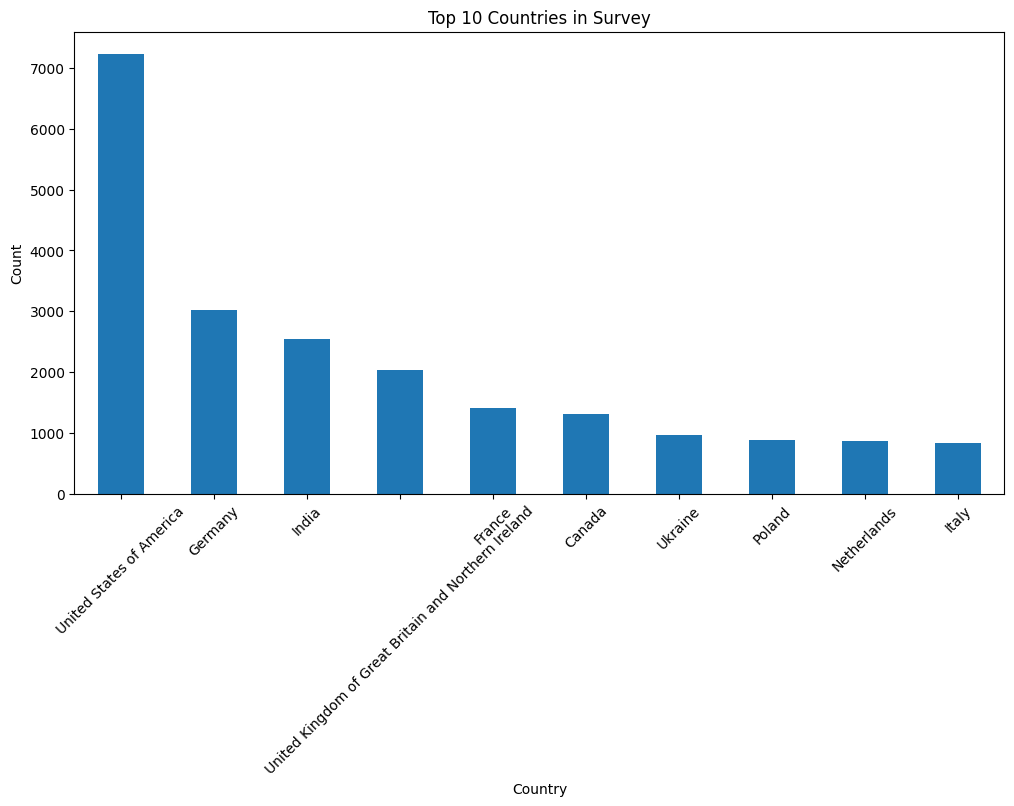

In [28]:
plt.figure(figsize=(12,6))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries in Survey")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

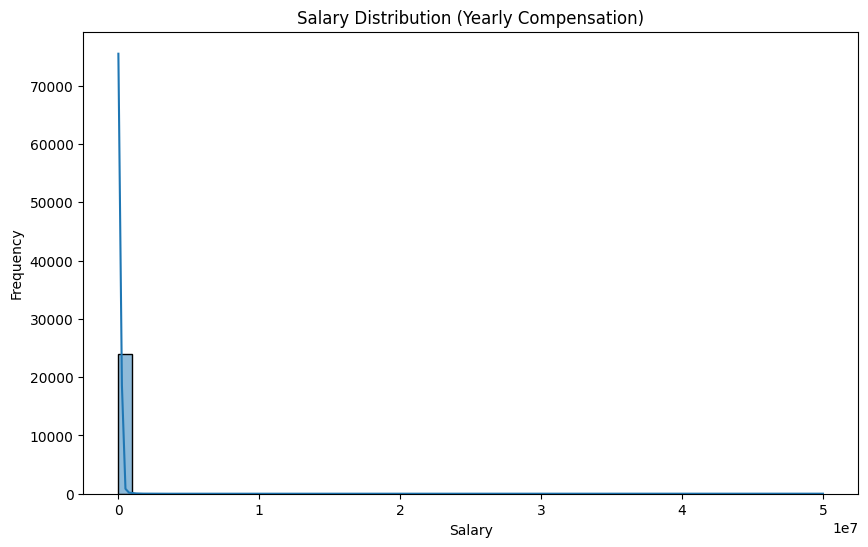

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(df["ConvertedCompYearly"], bins=50, kde=True)

plt.title("Salary Distribution (Yearly Compensation)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

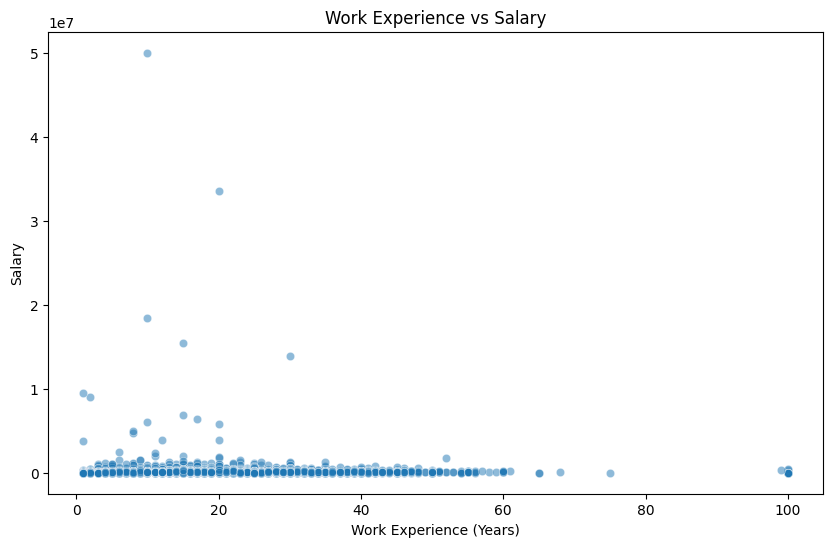

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="WorkExp",
    y="ConvertedCompYearly",
    alpha=0.5
)

plt.title("Work Experience vs Salary")
plt.xlabel("Work Experience (Years)")
plt.ylabel("Salary")
plt.show()

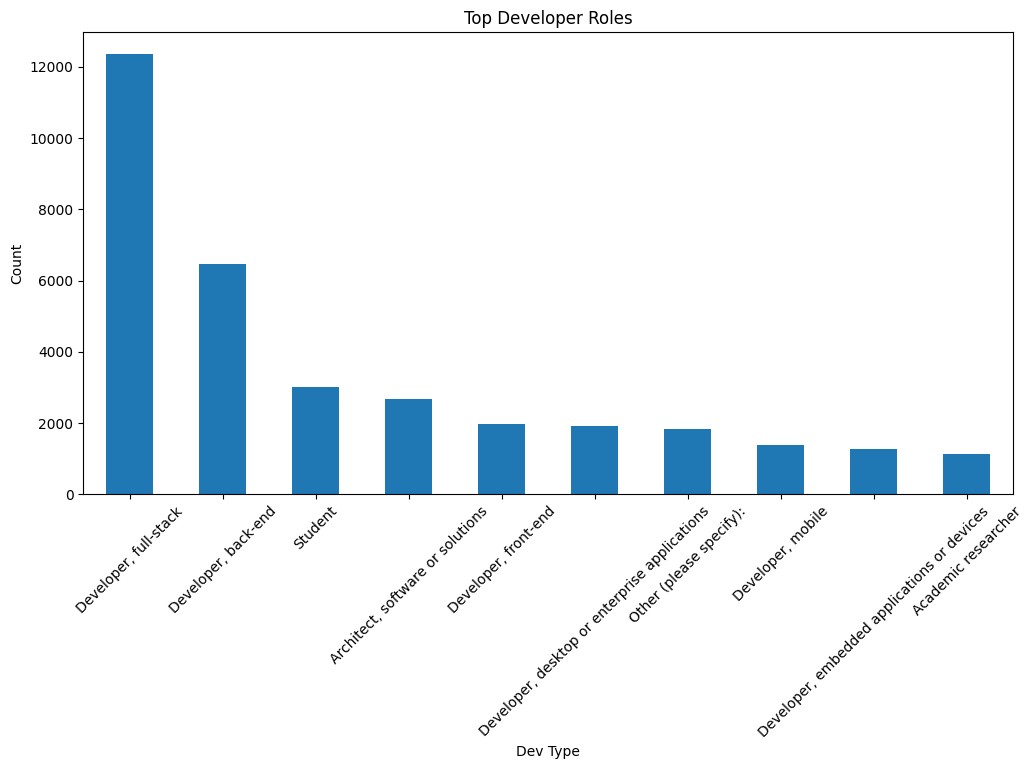

In [31]:
plt.figure(figsize=(12,6))

df["DevType"].value_counts().head(10).plot(kind="bar")

plt.title("Top Developer Roles")
plt.xlabel("Dev Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

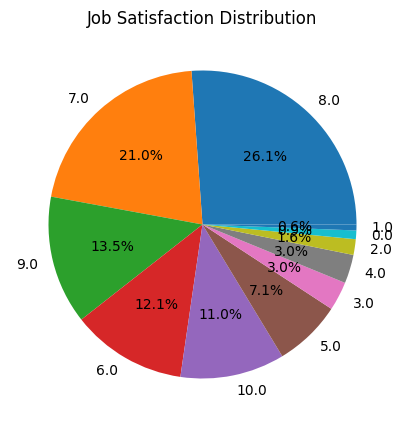

In [32]:
plt.figure(figsize=(8,5))

df["JobSat"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Job Satisfaction Distribution")
plt.ylabel("")
plt.show()

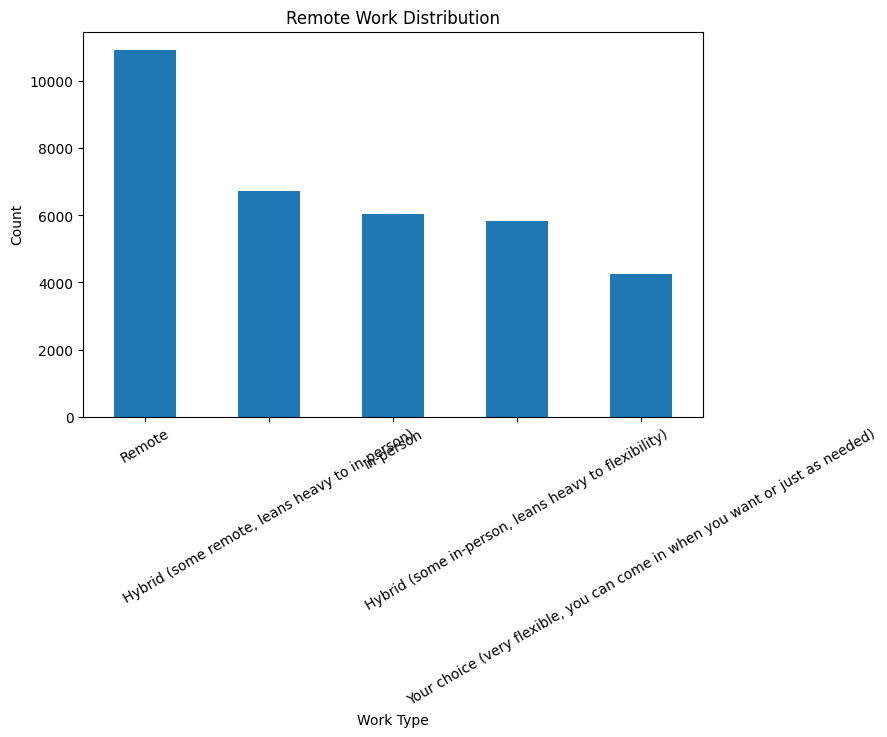

In [33]:
plt.figure(figsize=(8,5))

df["RemoteWork"].value_counts().plot(kind="bar")

plt.title("Remote Work Distribution")
plt.xlabel("Work Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()